### Watershed and Trail Analysis - Olivia ###

This notebook will be used for combining snow imagery code and feature geodataframes for analysis of snow extent in relation to watershed boundaries and trails. This will also be used for plotting results of our analysis. 

In [46]:
pip install dataretrieval

Note: you may need to restart the kernel to use updated packages.


In [47]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj
from pyproj import Transformer
import osmnx as ox
import contextily as ctx
import dataretrieval.nwis as nwis # use to pull from USGS
import requests
import easysnowdata
import rioxarray as rxr
import shapely
from shapely.geometry import box
from shapely.geometry import Point
import pystac_client
import planetary_computer
import odc.stac
import datetime
import rasterio as rio

# I was unable to add the ONP boundary to the plot's legend, this fix from a github discussion forum: https://github.com/geopandas/geopandas/issues/660
from matplotlib.legend import Legend
from matplotlib.collections import PatchCollection
from matplotlib.legend_handler import HandlerPolyCollection
from matplotlib.patches import Patch

from matplotlib.colors import ListedColormap

##### Load in features from various sources #####

In [48]:
# create geodataframe of Olympic National Park boundaries
onp = "Olympic National Park, Washington, USA"
onp_gdf = ox.geocode_to_gdf(onp)

# create geodataframe of ONP Trails within park boundaries
trails_gdf = ox.features.features_from_polygon(onp_gdf.geometry.iloc[0], {'highway': 'path'})

# create a watershed boundary gdf
# data from https://hub.arcgis.com/datasets/24c59727ba614c4aabe41f168ec3f586_11/explore?location=47.837590%2C-123.471642%2C9
# tried pulling from the API, but was unsuccessful after ~ an hour of troubleshooting, so I elected to just download the file
watersheds_gdf = gpd.read_file("data/NHD_-9030064575332258501.geojson")

In [49]:
# calling in the data from the Nationwide River Inventory (NRI) 
# used AI to help with API. It added the params and request part since calling in the url only brought in 1000 rivers, which didn't include those in ONP
rivers_url = "https://services1.arcgis.com/fBc8EJBxQRMcHlei/arcgis/rest/services/Nationwide_Rivers_Inventory_Official/FeatureServer/0/query"

params = {"where": """Management_Area_Name IN ('Olympic National Park', 'Olympic National Forest', 'Olympic National Park, Olympic National Forest',
                'The Brothers Wilderness')
            OR River LIKE '%Bogachiel%'""",
        "outFields": "*",
        "f": "geojson"}

r = requests.get(rivers_url, params=params)
rivers_gdf = gpd.read_file(r.text)

In [51]:
# create a geodataframe of USGS stations
# add USGS station locations - code from streamflow notebook

station_id = stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000]
stations_gdf = gpd.GeoDataFrame(station_id, columns=['station_id'])
river_list = ['Elwha', 'Duckabush', 'Skokomish', 'Quinault', 'Bogachiel', 'Hoh',
                    'Queets', 'Calawah', 'Dungeness']
stations_gdf.index = river_list
geom = []
# the 'dec_lat_va' and 'dec_long_va' were taken from AI since it was helping to navigate the USGS API
for station in station_id:
    coords = nwis.get_record(sites=str(station), service="site")
    lat = coords.iloc[0]['dec_lat_va'] 
    lon = coords.iloc[0]['dec_long_va']
    geom.append(Point(lon, lat))
    
stations_gdf['geometry'] = geom
stations_gdf.set_geometry(stations_gdf['geometry'])
# set crs given on the USGS site
stations_gdf = stations_gdf.set_crs('EPSG:4267')

In [52]:
# convert to UTM 10N crs
onp_gdf = onp_gdf.to_crs('EPSG:32610')    # 32610 - utm 10n   2926 - aea washington north
trails_gdf = trails_gdf.to_crs(onp_gdf.crs)
rivers_gdf = rivers_gdf.to_crs(onp_gdf.crs)
watersheds_gdf = watersheds_gdf.to_crs(onp_gdf.crs)
stations_gdf = stations_gdf.to_crs(onp_gdf.crs)

In [53]:
# set focus dates
high_start = '2022-07-15'
high_end = '2022-08-15'

low_start = '2023-07-15'
low_end = '2023-08-15'

med_start = '2020-07-15'
med_end = '2020-08-15'

In [54]:
# set resolution and bounding box
resolution = 20 # m
bbox_snow = (-124.4,47.45,-123,48.06)  # Rough bounds of ONP

In [55]:
# define function for snow extents

# function adapted from Owen's trial notebooks
def get_snow_extents(start_date, end_date):
    s2 = easysnowdata.remote_sensing.Sentinel2(
        bbox_input=bbox_snow,
        start_date=start_date,
        end_date=end_date,
        catalog_choice="planetarycomputer",
        resolution=resolution,
    )

    # get snow extents - there are some clear outliers that are present in the water!
    s2.get_ndsi()
    bad_scl = [0,1,2,3,6,8,9,10]
    ndsi_median_composite = s2.ndsi.where(~s2.data.scl.isin(bad_scl)).median(dim='time').compute() 
    snow_mask = (ndsi_median_composite > 0.4).astype(int)
    return snow_mask

In [56]:
# get snow extents for the period of interest in each year
snow_mask_2020 = get_snow_extents(med_start, med_end)
snow_mask_2022 = get_snow_extents(high_start, high_end)
snow_mask_2023 = get_snow_extents(low_start, low_end)

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.
Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_ol

In [57]:
# test if aea projection shows significant changes
# chose to stay in UTM 10 N projection because there were minimal changes to area calculations (>0.01 km^2 magnitude)

# snow_mask_2020 = snow_mask_2020.rio.write_crs('EPSG:32610')
# snow_mask_2022 = snow_mask_2022.rio.write_crs('EPSG:32610')
# snow_mask_2023 = snow_mask_2023.rio.write_crs('EPSG:32610')

# snow_mask_2020 = snow_mask_2020.rio.reproject(onp_gdf.crs)
# snow_mask_2022 = snow_mask_2022.rio.reproject(onp_gdf.crs)
# snow_mask_2023 = snow_mask_2023.rio.reproject(onp_gdf.crs)

In [58]:
# set x and y limits of the plot
bounds = onp_gdf.total_bounds
xmin, xmax, ymin, ymax = bounds[0], bounds[2], bounds[1], bounds[3]
buffer = 10000

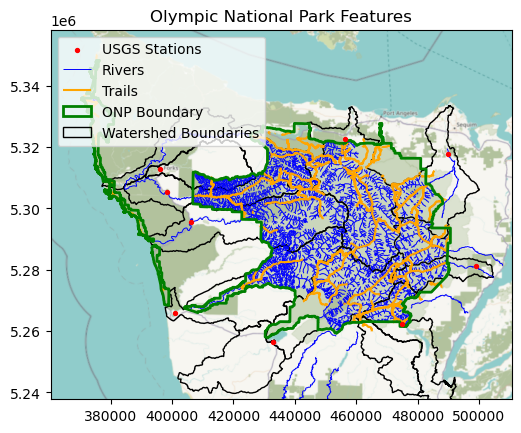

In [59]:
# plot everything together

# fix for legend that was mentioned above
Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})

fig, ax = plt.subplots()

# rgb_median_composite_2020.plot.imshow(ax=ax, robust=True)
# snow_mask_2020.plot.imshow(ax=ax, cmap='RdBu_r', zorder=1, robust=True, vmin=-1, vmax=1)
stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red', zorder=5, label='USGS Stations')
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.7, zorder=2, label='Rivers')
trails_gdf.plot(ax=ax, color='orange', zorder=3, label='Trails')
onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=4, label='ONP Boundary')
watersheds_gdf.plot(ax=ax, facecolor='None', edgecolor='k', linewidth=1, zorder=1, label='Watershed Boundaries')
ax.set_title("Olympic National Park Features")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
# ax.grid(True)
ax.set_xlim(xmin-buffer, xmax+2*buffer)
ax.set_ylim(ymin-2*buffer, ymax+buffer)
ax.legend(loc='upper left')

In [60]:
# functions from streamflow plots notebook to add streamflow plots next to our watershed plots
def usgs_discharge(station, start_date, end_date):
    df = nwis.get_record(
        sites=station, # station ID 
        service="dv", # daily values
        start=start_date, # YYYY-MM-DD
        end=end_date, # YYYY-MM-DD
        parameterCd="00060") # pulls discharge data
    df['Q_cms'] = df['00060_Mean'] * 0.028316847 # convert discharge from cfs to cubic meters per second
    return df

In [61]:
# determine extent of snow within each watershed - make a function and call for the list of watersheds in watersheds_gdf
def snow_extent_in_watershed(snow_mask, watershed): 
    snow_extent = snow_mask.where(snow_mask > 0.5)
    snow = snow_extent.rio.clip([watershed.iloc[0].geometry]) # snow within the watershed boundaries
    snow_pixels_in_watershed = int(snow.sum())
    res = resolution
    area = snow_pixels_in_watershed*((res*res)/1E6) # area of snow in the watershed boundaries in km
    return snow, area

In [62]:
# define function to perform analysis of each watershed and optimize features for plotting

# this is the old version with the stream flow plot having a single line and highlights for each period of interest, this wasn't the best for comparing between water years
# keeping this for reference incase we want to look at that style of streamflow plot

def analyze_and_plot_watershed_OLD(snow_mask_2020, snow_mask_2022, snow_mask_2023, watershed):
    snow_2020, area_2020 = snow_extent_in_watershed(snow_mask_2020, watershed) # analyze extent of snow in watershed with predefined function
    snow_plot_2020 = snow_2020.where(snow_2020 == 1)
    snow_2022, area_2022 = snow_extent_in_watershed(snow_mask_2022, watershed)
    snow_plot_2022 = snow_2022.where(snow_2022 == 1)
    snow_2023, area_2023 = snow_extent_in_watershed(snow_mask_2023, watershed)
    snow_plot_2023 = snow_2023.where(snow_2023 == 1)
    rivers_in_watershed = gpd.clip(rivers_gdf, watershed) # clip rivers to within watershed bounds
    usgs_station_in_watershed = gpd.clip(stations_gdf, watershed) # clip usgs station to watershed bounds

    # run stramflow plot functons for desired river
    # have dates run through all water years of interest
    start_date = '2019-10-01'
    end_date = '2023-09-30'
    df = usgs_discharge(str(usgs_station_in_watershed.iloc[0].station_id), start_date, end_date)  
    
    Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})
    # plot results of snow analysis alongside the streamflow plot for that river  
    fig, ax = plt.subplot_mosaic([['A', 'B', 'C'], ['D', 'D', 'D']], layout='tight', figsize=(15,10))

    # plot snow analysis
    # WY 2020
    watershed.plot(ax=ax['A'], facecolor='None', edgecolor='black', linewidth=1, zorder=2, label='Watershed Boundaries')
    # used AI to get this listed colormap to plot the 1s as a single color instead of having distribution of colors
    snow_plot_2020.plot.imshow(ax=ax['A'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['A'], color='blue', linewidth=0.7, zorder=3, label='Rivers')
    ax['A'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2020)")
    ctx.add_basemap(ax=ax['A'], attribution = '', crs=onp_gdf.crs) 
    ax['A'].text(0.05, 0.05, f"Snow Area: {area_2020:.2f} km$^2$", transform=ax['A'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    # used AI to adapt legend to include snow extent. AI provided the snow_patch and ax.get_legend_handles_label() lines. 
    # Traditional method of adding a label in the plot line was not working
    handles, labels = ax['A'].get_legend_handles_labels()
    snow_patch = Patch(color='red', label='Snow Extent')
    handles.append(snow_patch)

    # WY 2022
    watershed.plot(ax=ax['B'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2022.plot.imshow(ax=ax['B'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['B'], color='blue', linewidth=0.7, zorder=3)
    ax['B'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2022)")
    ctx.add_basemap(ax=ax['B'], attribution = '', crs=onp_gdf.crs)
    ax['B'].text(0.05, 0.05, f"Snow Area: {area_2022:.2f} km$^2$", transform=ax['B'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    # WY 2023
    watershed.plot(ax=ax['C'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2023.plot.imshow(ax=ax['C'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['C'], color='blue', linewidth=0.7, zorder=3)
    ax['C'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2023)")
    ctx.add_basemap(ax=ax['C'], attribution = '', crs=onp_gdf.crs)
    ax['C'].text(0.05, 0.05, f"Snow Area: {area_2023:.2f} km$^2$", transform=ax['C'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), handles=handles, ncol=3)
    
    # plot streamflow
    df['Q_cms'].plot(ax=ax['D'], label='Streamflow')
    ax['D'].set_xlabel('Date')
    ax['D'].set_ylabel('Discharge (m³/s)')
    ax['D'].set_title(f"{watershed['Name'].iloc[0]} Discharge Time Series")
    
    # add highlights of periods of interest
    ax['D'].axvline(pd.Timestamp(high_start), color='olivedrab', linestyle='--')
    ax['D'].axvline(pd.Timestamp(high_end), color='olivedrab', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(high_start), pd.Timestamp(high_end), color='yellowgreen', alpha=0.3, label='High WY')
    
    ax['D'].axvline(pd.Timestamp(low_start), color='palevioletred', linestyle='--')
    ax['D'].axvline(pd.Timestamp(low_end), color='palevioletred', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(low_start), pd.Timestamp(low_end), color='pink', alpha=0.3, label='Low WY')
    
    ax['D'].axvline(pd.Timestamp(med_start), color='gold', linestyle='--')
    ax['D'].axvline(pd.Timestamp(med_end), color='gold', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(med_start), pd.Timestamp(med_end), color='yellow', alpha=0.3, label='Medium WY')
    ax['D'].legend()
    
    return fig, ax

In [106]:
# alternative version of earlier function to plot streamflows over each other for better comparison
# going to use the outputs of this function

def analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watershed):
    snow_2020, area_2020 = snow_extent_in_watershed(snow_mask_2020, watershed) # analyze extent of snow in watershed with predefined function
    snow_plot_2020 = snow_2020.where(snow_2020 == 1)
    snow_2022, area_2022 = snow_extent_in_watershed(snow_mask_2022, watershed)
    snow_plot_2022 = snow_2022.where(snow_2022 == 1)
    snow_2023, area_2023 = snow_extent_in_watershed(snow_mask_2023, watershed)
    snow_plot_2023 = snow_2023.where(snow_2023 == 1)
    rivers_in_watershed = gpd.clip(rivers_gdf, watershed) # clip rivers to within watershed bounds
    usgs_station_in_watershed = gpd.clip(stations_gdf, watershed) # clip usgs station to watershed bounds

    # run stramflow plot functons for desired river
    # have dates run through all water years of interest
    start_date = '2019-10-01'
    end_date = '2023-09-30'
    df = usgs_discharge(str(usgs_station_in_watershed.iloc[0].station_id), start_date, end_date)  
    
    Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})
    # plot results of snow analysis alongside the streamflow plot for that river  
    fig, ax = plt.subplot_mosaic([['A', 'B', 'C'], ['D', 'D', 'D']], layout='tight', figsize=(15,10))

    # plot snow analysis
    # WY 2020
    watershed.plot(ax=ax['A'], facecolor='None', edgecolor='black', linewidth=1, zorder=2, label='Watershed Boundaries')
    # used AI to get this listed colormap to plot the 1s as a single color instead of having distribution of colors
    snow_plot_2020.plot.imshow(ax=ax['A'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['A'], color='blue', linewidth=0.7, zorder=3, label='Rivers')
    ax['A'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2020)")
    ctx.add_basemap(ax=ax['A'], attribution = '', crs=onp_gdf.crs) 
    ax['A'].text(0.05, 0.05, f"Snow Area: {area_2020:.2f} km^2", transform=ax['A'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    # used AI to adapt legend to include snow extent. AI provided the snow_patch and ax.get_legend_handles_label() lines. 
    # Traditional method of adding a label in the plot line was not working
    handles, labels = ax['A'].get_legend_handles_labels()
    snow_patch = Patch(color='red', label='Snow Extent')
    handles.append(snow_patch)

    # WY 2022
    watershed.plot(ax=ax['B'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2022.plot.imshow(ax=ax['B'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['B'], color='blue', linewidth=0.7, zorder=3)
    ax['B'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2022)")
    ctx.add_basemap(ax=ax['B'], attribution = '', crs=onp_gdf.crs)
    ax['B'].text(0.05, 0.05, f"Snow Area: {area_2022:.2f} km^2", transform=ax['B'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    # WY 2023
    watershed.plot(ax=ax['C'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2023.plot.imshow(ax=ax['C'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['C'], color='blue', linewidth=0.7, zorder=3)
    ax['C'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2023)")
    ctx.add_basemap(ax=ax['C'], attribution = '', crs=onp_gdf.crs)
    ax['C'].text(0.05, 0.05, f"Snow Area: {area_2023:.2f} km^2", transform=ax['C'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), handles=handles, ncol=3)
    
    # plot streamflow
    # get in terms of DOWY so years can be plotted over each other

    # 'start ='  line for the function 'add_dowy_to_df came from AI
    def add_dowy_to_df(df, water_year):
        start = pd.Timestamp(f"{water_year-1}-10-01", tz=df.index.tz)
        dowy = (df.index - start).days + 1
        df['DOWY'] = dowy
        return df

    # had to add the .copy() because I got an error from pandas
    # plotting the whole year with a highlight on our time of interest

    # calculate mean annual discharge and mean discharge over the period of interest for each water year for correlation calculations
    wy_2020 = add_dowy_to_df(df.loc['2019-10-01':'2020-09-30'].copy(), 2020)
    flow_2020 = wy_2020['Q_cms'].mean()
    flow_pi_2020 = wy_2020['Q_cms'].loc[med_start:med_end].mean()
    wy_2022 = add_dowy_to_df(df.loc['2021-10-01':'2022-09-30'].copy(), 2022)
    flow_2022 = wy_2022['Q_cms'].mean()
    flow_pi_2022 = wy_2022['Q_cms'].loc[high_start:high_end].mean()
    wy_2023 = add_dowy_to_df(df.loc['2022-10-01':'2023-09-30'].copy(), 2023)
    flow_2023 = wy_2023['Q_cms'].mean()
    flow_pi_2023 = wy_2023['Q_cms'].loc[low_start:low_end].mean()

    # july 15th = 285th day of water year
    # august 15th = 318th day of water year with leap year, whcih 2022 has
    ax['D'].axvline(286, color='gold', linestyle='--')
    ax['D'].axvline(318, color='gold', linestyle='--')
    ax['D'].axvspan(286, 318, color='yellow', alpha=0.3, label='Period of Interest')
    
    ax['D'].plot(wy_2020['DOWY'], wy_2020['Q_cms'], color='goldenrod', label='Med WY')
    ax['D'].plot(wy_2022['DOWY'], wy_2022['Q_cms'], color='olivedrab', label='High WY')
    ax['D'].plot(wy_2023['DOWY'], wy_2023['Q_cms'], color='deeppink', label='Low WY')
   
    ax['D'].set_xlabel('DOWY')
    ax['D'].set_ylabel('Discharge (m³/s)')
    ax['D'].set_title(f"{watershed['Name'].iloc[0]} Discharge Time Series")
    ax['D'].legend()

    # create a dataframe to calculate correlation between mean annual discharge and summer snow extent
    corr_df = pd.DataFrame({
        'water_year': [2020, 2022, 2023],
        'snow_area': [area_2020, area_2022, area_2023], # km2
        'mean_discharge': [flow_2020, flow_2022, flow_2023], # cms
        'mean_discharge_pi': [flow_pi_2020, flow_pi_2022, flow_pi_2023]})  # cms

    correlation = corr_df['snow_area'].corr(corr_df['mean_discharge'])
    # calculate correlation for the period of mean discharge over the period of interest
    correlation_pi = corr_df['snow_area'].corr(corr_df['mean_discharge_pi'])
    
    return fig, ax, correlation, correlation_pi

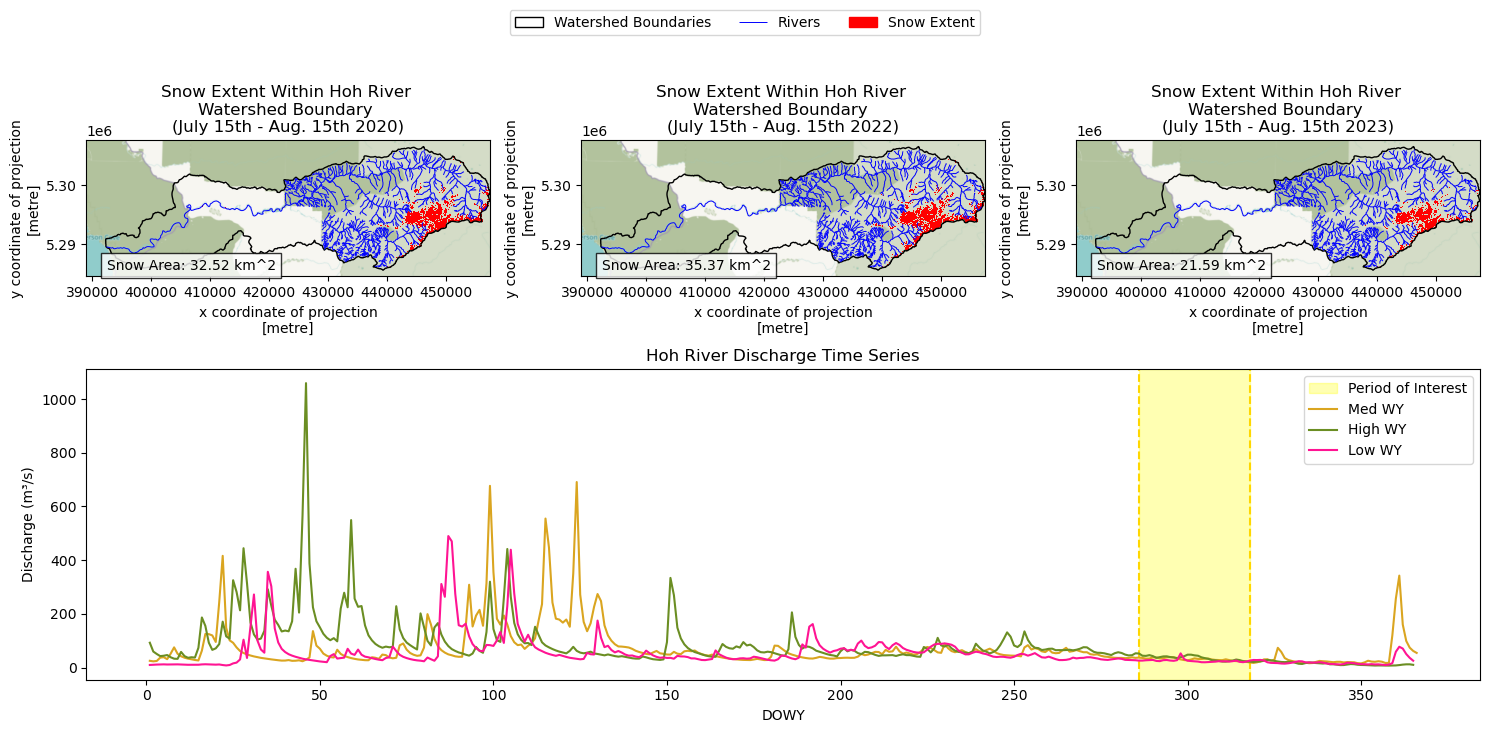

In [97]:
# trial for a watershed
fig_hoh, ax_hoh, correlation_hoh, correlation_pi_hoh = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[7]])
# Queets (3), Elwha (9), Dungeness (5), Hoh (7) (really like for representing the analysis)

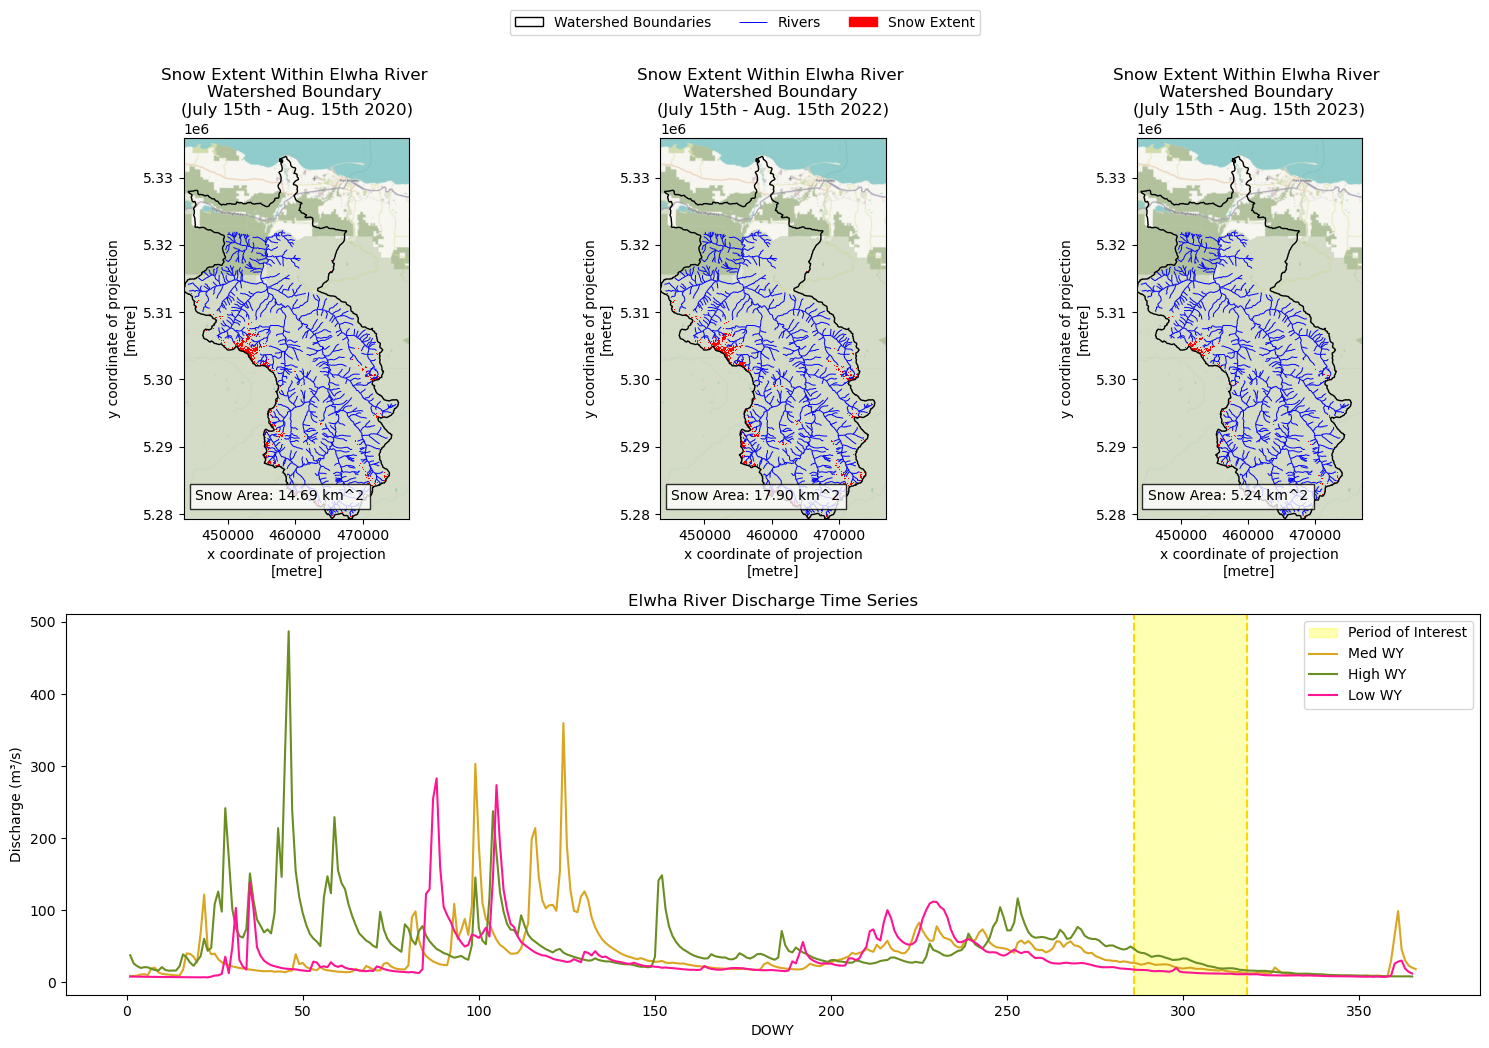

In [107]:
# changed the figure size slightly for this one to accommodate the more vertical orientation of the watershed
fig_elwha, ax_elwha, correlation_elwha, correlation_pi_elwha = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[9]])

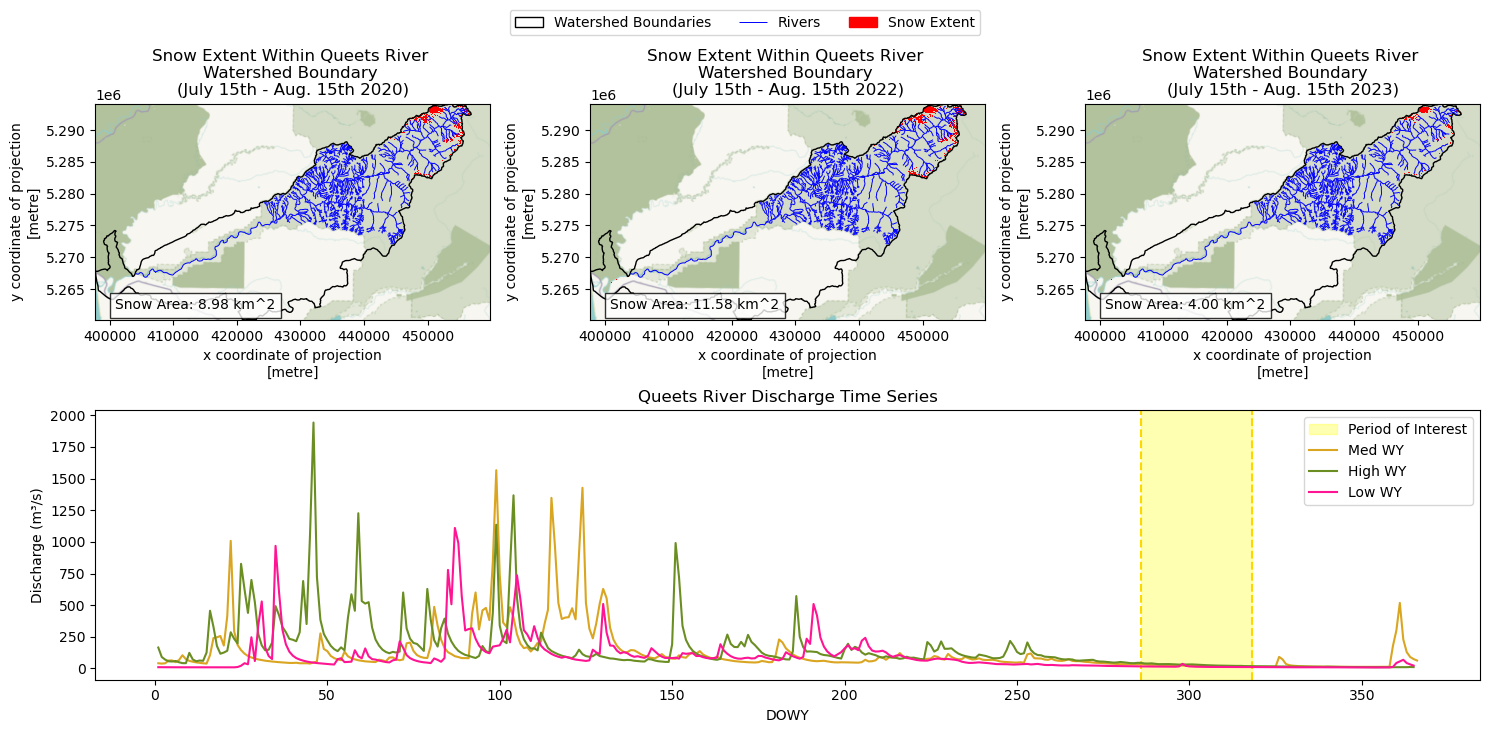

In [99]:
fig_queets, ax_queets, correlation_queets, correlation_pi_queets = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[3]])

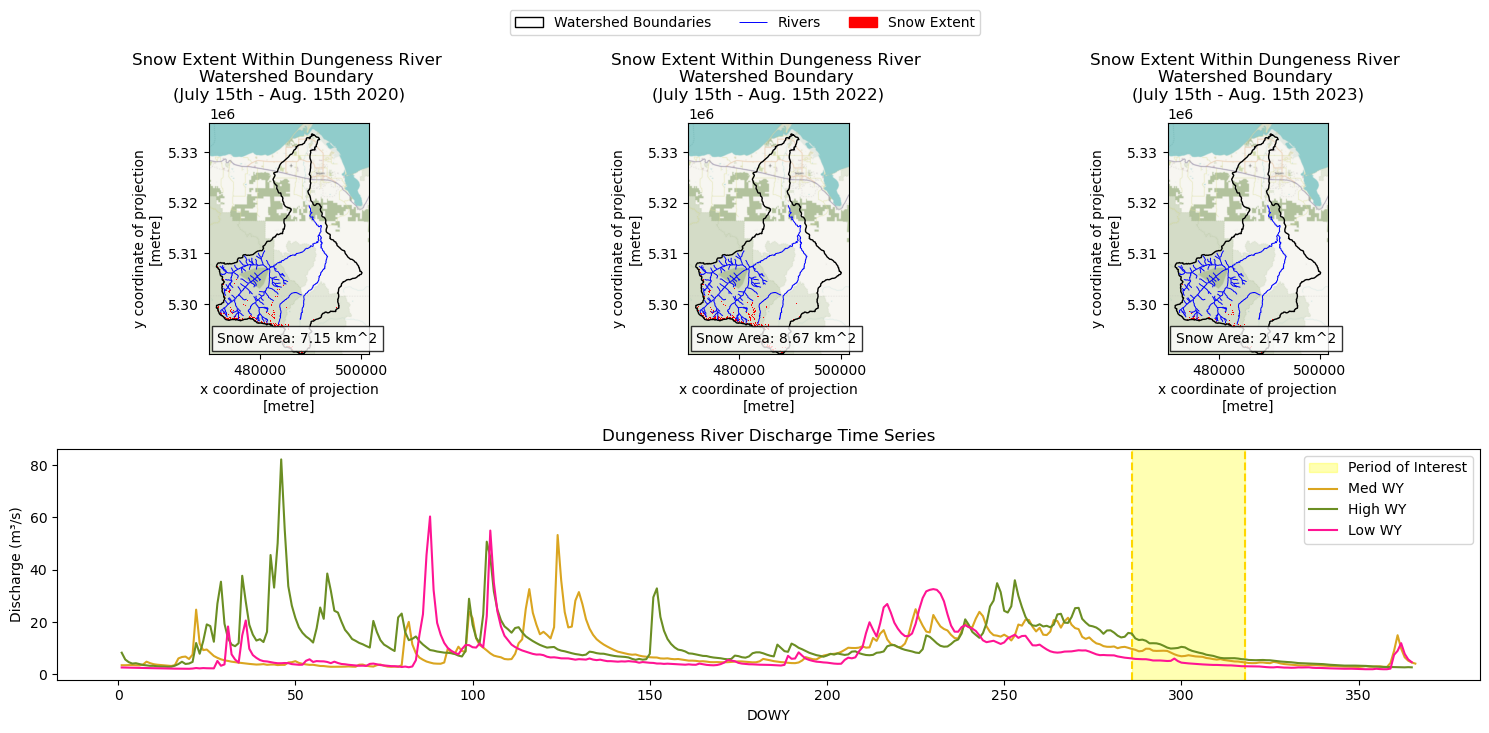

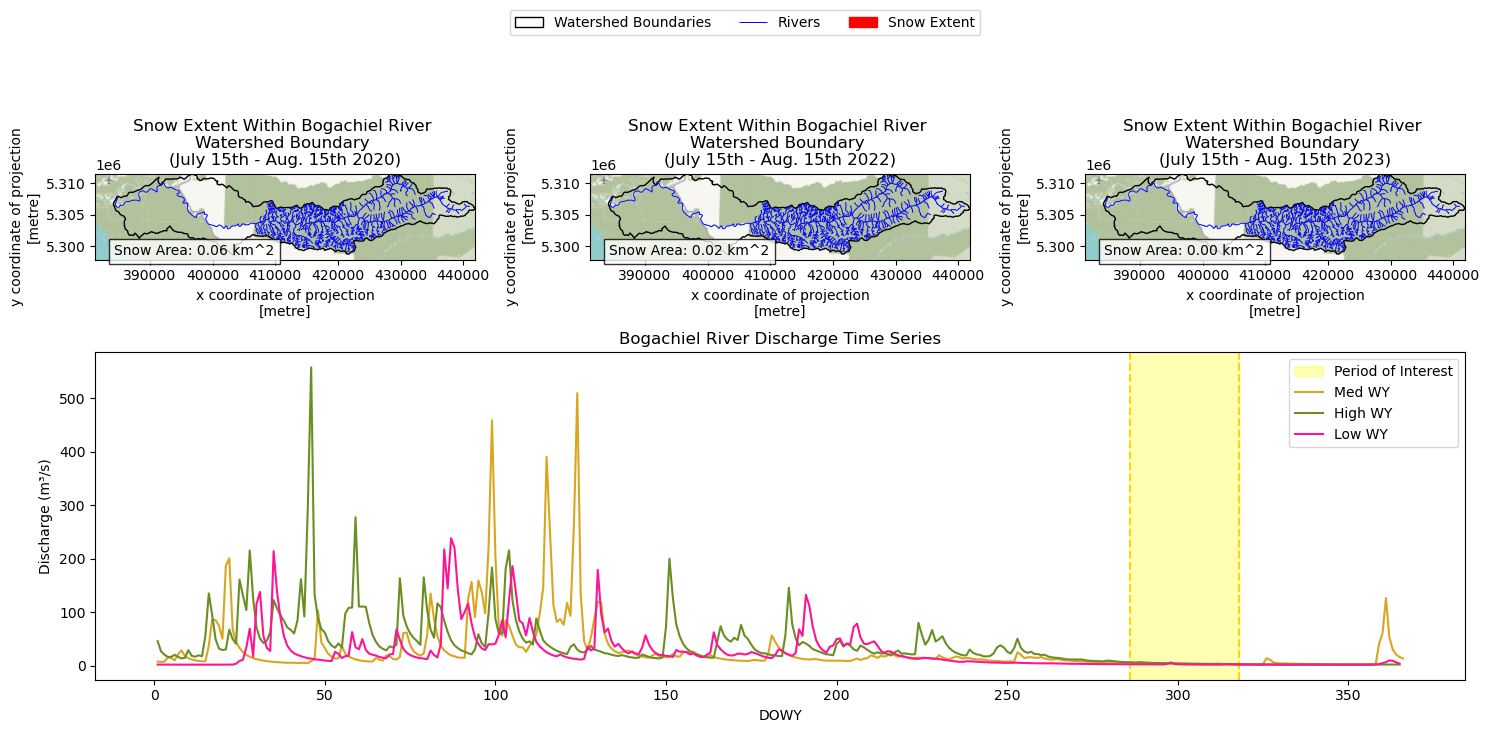

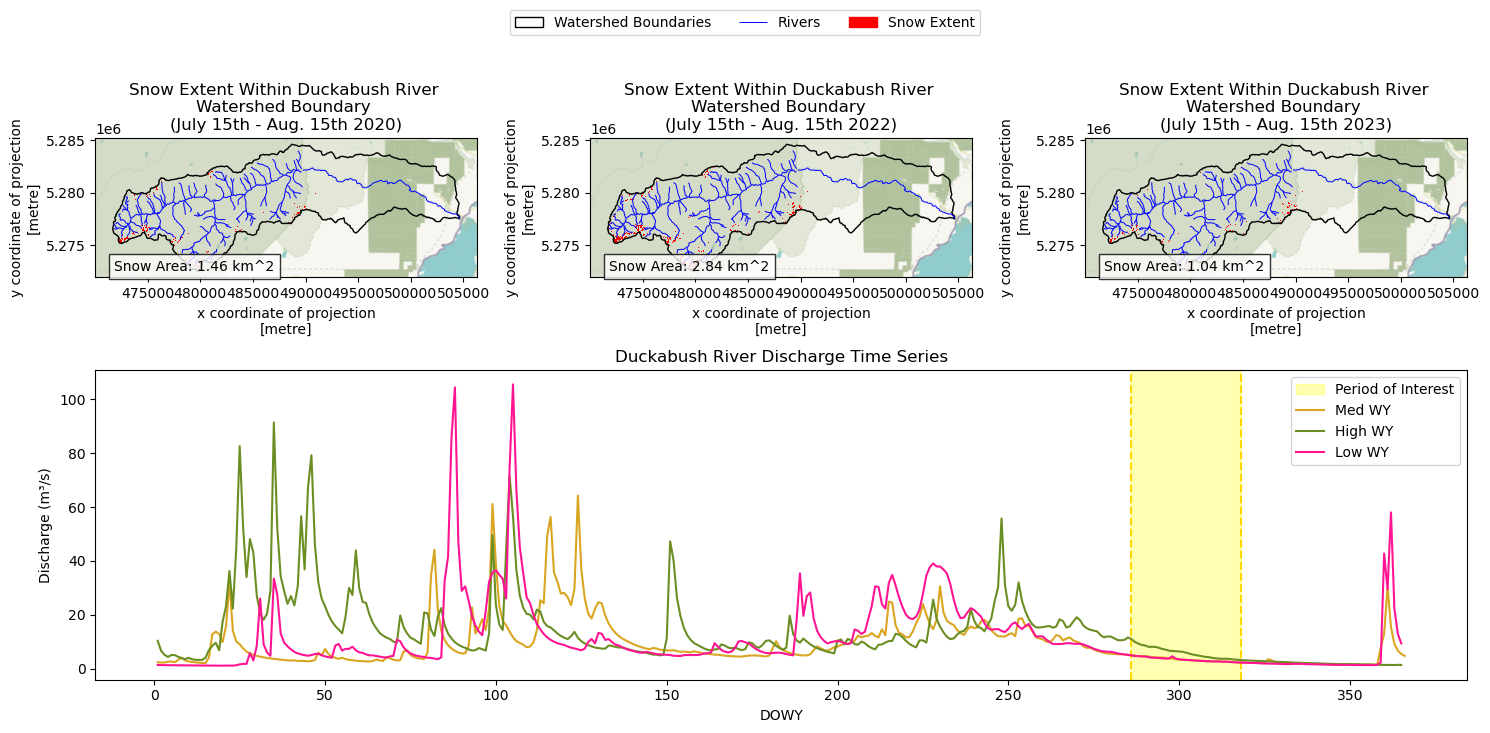

In [104]:
# calculate a few more correlation values
_, _, correlation_dungeness, correlation_pi_dungeness = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[5]])
_, _, correlation_bogachiel, correlation_pi_bogachiel = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[10]])
_, _, correlation_duckabush, correlation_pi_duckabush = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[8]])

In [105]:
print(f"Correlation between snow extent in watershed and mean annual discharge for sample watersheds \nHoh River: {correlation_hoh:.4f}" 
    f"\nElwha River: {correlation_elwha:.4f} \nQueets River: {correlation_queets:4f} \nDungeness River: {correlation_dungeness:.4f}"
     f"\nBogachiel River: {correlation_bogachiel:.4f} \nDuckabush River: {correlation_duckabush:.4f}")

print(f"Correlation between snow extent in watershed and mean discharge over the period of interest for sample watersheds \nHoh River: {correlation_pi_hoh:.4f}" 
    f"\nElwha River: {correlation_pi_elwha:.4f} \nQueets River: {correlation_pi_queets:4f} \nDungeness River: {correlation_pi_dungeness:.4f}"
     f"\nBogachiel River: {correlation_pi_bogachiel:.4f} \nDuckabush River: {correlation_pi_duckabush:.4f}")

Correlation between snow extent in watershed and mean annual discharge for sample watersheds 
Hoh River: 0.9702
Elwha River: 0.8811 
Queets River: 0.982632 
Dungeness River: 0.8532
Bogachiel River: 0.1231 
Duckabush River: 0.7506
Correlation between snow extent in watershed and mean discharge over the period of interest for sample watersheds 
Hoh River: 0.9477
Elwha River: 0.9186 
Queets River: 0.980026 
Dungeness River: 0.9739
Bogachiel River: 0.5345 
Duckabush River: 0.9719


From these correlation results, we see that areas with less snow extent overall have lower correlation coefficients, which makes sense because streamflow would rely more heavily on non snow resources for stream supply.

In [68]:
# trail buffer
trail_buffer = trails_gdf.buffer(500)
trails_buffer_gdf = trails_gdf.copy()
trails_buffer_gdf.geometry = trail_buffer
trails_buffer_combined = trails_buffer_gdf.union_all()

In [69]:
def snow_extent_in_trail_buffer(snow_mask, trails): 
    snow_extent = snow_mask.where(snow_mask > 0.5)
    snow = snow_extent.rio.clip([trails]) # snow within the trail
    snow_plot = snow.where(snow == 1)
    snow_pixels_in_trail_buffer = int(snow.sum())
    res = resolution
    area = snow_pixels_in_trail_buffer*((res*res)/1E6) # area of snow in the watershed boundaries in km
    return snow_plot, area

In [70]:
snow_low, area_low = snow_extent_in_trail_buffer(snow_mask_2023, trails_buffer_combined)
snow_high, area_high = snow_extent_in_trail_buffer(snow_mask_2022, trails_buffer_combined)
snow_med, area_med = snow_extent_in_trail_buffer(snow_mask_2020, trails_buffer_combined)

In [71]:
print(f"Snow Area within 500 m of ONP Trails \nWY 2020: {area_med:.2f} km² \nWY 2022: {area_high:.2f} km² \nWY 2023: {area_low:.2f} km²")

Snow Area within 500 m of ONP Trails 
WY 2020: 4.91 km² 
WY 2022: 7.13 km² 
WY 2023: 1.76 km²


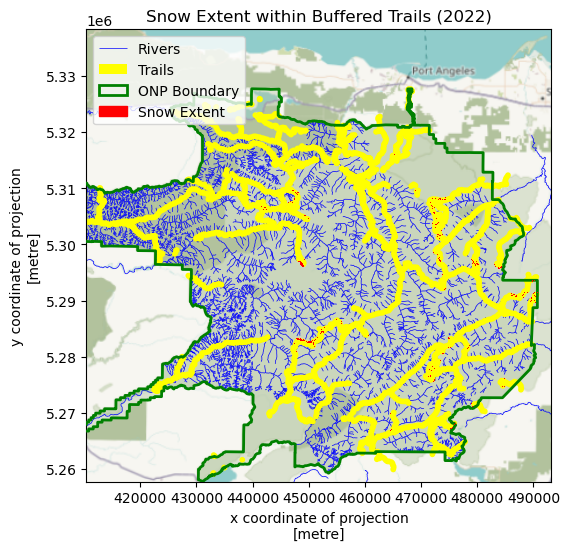

In [72]:
fig, ax = plt.subplots(figsize=(6,6))

snow_high.plot.imshow(ax=ax, zorder=4, cmap=ListedColormap(['red']), add_colorbar=False)
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.5, zorder=1, label='Rivers')
trails_buffer_gdf.plot(ax=ax, color='yellow', zorder=2, label='Trails')
onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=3, label='ONP Boundary')
ax.set_title("Snow Extent within Buffered Trails (2022)")
handles, labels = ax.get_legend_handles_labels()
snow_patch = Patch(color='red', label='Snow Extent')
handles.append(snow_patch)
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
ax.set_xlim(xmin+4*buffer, xmax+2500)
ax.set_ylim(ymin, ymax-10000)
ax.legend(loc='upper left', handles=handles)